In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pathlib
import cv2
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import models, layers

from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.applications import DenseNet121

from tensorflow.keras import optimizers
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/gender_dataset_face"
type(data_dir)

str

In [ ]:
data_dir = pathlib.Path(data_dir)
type(data_dir)

pathlib.PosixPath

In [ ]:
data_dir.glob("*")

<generator object Path.glob at 0x7e5f1cb8dbe0>

In [ ]:
list(data_dir.glob("*"))

[PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/man'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman')]

In [ ]:
list(data_dir.glob("woman/*"))

[PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_561.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_457.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_417.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_43.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_387.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_419.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_415.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1050.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1242.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1087.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_fa

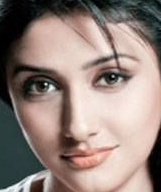

In [ ]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("woman/*"))[17]))

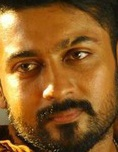

In [ ]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("man/*"))[30]))

In [ ]:
print(len(list(data_dir.glob("woman/*"))))
print(len(list(data_dir.glob("man/*"))))

1134
1173


In [ ]:
1134 + 1173

2307

In [ ]:
gender_images_dict = {
    'Woman': list(data_dir.glob('woman/*')),
    'Man': list(data_dir.glob('man/*')),
}
gender_labels_dict = {
    'Woman': 0,
    'Man': 1,
}

In [ ]:
# X, y = [], []

# for gender, images in gender_images_dict.items():
#     for image in images:
#         img = cv2.imread(image)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         resized_img = cv2.resize(img,(224,224))
#         resized_img = preprocess_input(resized_img)

#         X.append(resized_img)
#         y.append(gender_labels_dict[gender])

In [ ]:
# X = np.array(X)
# y = np.array(y)

In [ ]:
# np.savez_compressed("/content/drive/MyDrive/Colab Notebooks/gender_dataset_DenseNet.npz", X=X, y=y)

In [ ]:
data = np.load("/content/drive/MyDrive/Colab Notebooks/gender_dataset_DenseNet.npz")

X = data["X"]
y = data["y"]

In [ ]:
X.shape

(2307, 224, 224, 3)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1765,
    stratify=y_train,
    random_state=42
)

In [ ]:
print("Train:", np.bincount(y_train_final))
print("Validation:", np.bincount(y_val))
print("Test:", np.bincount(y_test))

Train: [793 821]
Validation: [170 176]
Test: [171 176]


class distribution remains consistent across splits

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode="nearest"
)

train_generator = train_datagen.flow(
    x_train_final,
    y_train_final,
    batch_size=32,
    shuffle=True
)

In [ ]:
val_datagen = ImageDataGenerator()

val_generator = val_datagen.flow(
    x_val,
    y_val,
    batch_size=32,
    shuffle=False
)

**Insights:**

Data augmentation was applied to the training data to simulate real-world variations such as slight rotations, shifts, zoom, and lighting changes. This helps the model generalize better and reduces overfitting by exposing it to more diverse facial patterns during training, while validation data remained unchanged to ensure unbiased evaluation.

# C. DenseNet121:-

In [ ]:
checkpointer = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Colab Notebooks/gender_detection_best_DenseNet121_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
base_model = DenseNet121(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
densenet_model = models.Sequential()

densenet_model.add(base_model)

densenet_model.add(layers.GlobalAveragePooling2D())

densenet_model.add(layers.Dense(128, activation='relu'))
densenet_model.add(layers.Dropout(0.4))

densenet_model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
densenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
densenet_model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_densenet = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[checkpointer, early_stop, lr_reduce],
    verbose=2
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40

Epoch 1: val_loss improved from inf to 0.57309, saving model to /content/drive/MyDrive/Colab Notebooks/gender_detection_best_DenseNet121_model.keras
51/51 - 90s - 2s/step - accuracy: 0.5719 - loss: 0.7148 - val_accuracy: 0.7486 - val_loss: 0.5731 - learning_rate: 3.0000e-05
Epoch 2/40

Epoch 2: val_loss improved from 0.57309 to 0.47568, saving model to /content/drive/MyDrive/Colab Notebooks/gender_detection_best_DenseNet121_model.keras
51/51 - 25s - 490ms/step - accuracy: 0.7069 - loss: 0.5819 - val_accuracy: 0.8555 - val_loss: 0.4757 - learning_rate: 3.0000e-05
Epoch 3/40

Epoch 3: val_loss improved from 0.47568 to 0.40098, saving model to /content/drive/MyDrive/Colab Notebooks/gender_detection_best_DenseNet121_model.keras
51/51 - 25s - 487ms/step - accuracy: 0.7726 - loss: 0.5008 - val_accuracy: 0.9075 - val_loss: 0.4010 - learning_rate: 3.0000e-05
Epoch 4/40

Epoch 4: val_loss improved from 0.40098 to 0.35242, saving model to /content/drive/MyDrive/Colab Notebooks/gender

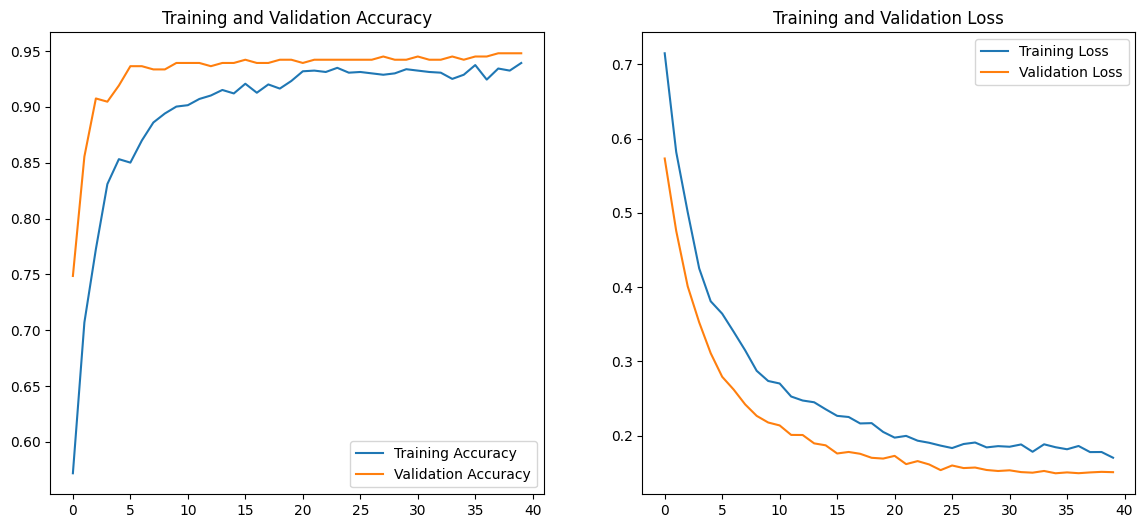

In [ ]:
 # Plot training metrics
acc = history_densenet.history['accuracy']
val_acc = history_densenet.history['val_accuracy']
loss = history_densenet.history['loss']
val_loss = history_densenet.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
densenet_model.evaluate(x_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9397 - loss: 0.1644


[0.15114055573940277, 0.9510086178779602]

In [ ]:
y_pred_prob = densenet_model.predict(x_test)

y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       171
           1       0.95      0.95      0.95       176

    accuracy                           0.95       347
   macro avg       0.95      0.95      0.95       347
weighted avg       0.95      0.95      0.95       347



>DenseNet121 was implemented using transfer learning with pretrained ImageNet weights to improve gender classification performance. The dense connectivity between layers allows feature reuse and efficient gradient propagation, enabling the model to learn rich facial representations even with a relatively small dataset. The model achieved 95% test accuracy, with balanced precision, recall, and F1-scores for both classes, indicating strong generalization and reliable gender prediction. These results demonstrate that deeper pretrained architectures significantly outperform custom CNN models by effectively capturing subtle facial features relevant for gender classification.

## Model Performance Comparison

| Model | Input Size | Accuracy | Precision | Recall | F1-Score |
|------|------------|----------|-----------|--------|---------|
| Custom CNN | 224×224 | 0.67 | 0.67 | 0.67 | 0.67 |
| MobileNetV2 | 224×224 | 0.93 | 0.93 | 0.93 | 0.93 |
| DenseNet121 | 224×224 | 0.95 | 0.95 | 0.95 | 0.95 |
| **ResNet50** | 224×224 | **0.96** | **0.96** | **0.96** | **0.96** |

---

### Key Observations

- **Transfer learning significantly improved performance** compared to the custom CNN baseline.
- **ResNet50 achieved the best overall performance**, reaching **96% accuracy**.
- **DenseNet121 performed very close to ResNet50**, indicating strong feature propagation.
- **MobileNetV2 provided strong accuracy with a lightweight architecture**, making it suitable for efficient deployments.

## Final Model Selection

Among all evaluated architectures, **ResNet50 achieved the best overall performance with a test accuracy of 96%**.  
The model demonstrated stable training behavior and balanced precision, recall, and F1-score.

Therefore, **ResNet50 was selected as the final model for the gender classification task**.